<a href="https://www.kaggle.com/code/sonawanelalitsunil/blinkit-sales-insights-trends-perform-99?scriptVersionId=223117599" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/blinkit-sales-dataset/blinkit_customer_feedback.csv
/kaggle/input/blinkit-sales-dataset/blinkit_customers.csv
/kaggle/input/blinkit-sales-dataset/blinkit_order_items.csv
/kaggle/input/blinkit-sales-dataset/Category_Icons.xlsx
/kaggle/input/blinkit-sales-dataset/blinkit_inventory.csv
/kaggle/input/blinkit-sales-dataset/blinkit_delivery_performance.csv
/kaggle/input/blinkit-sales-dataset/Rating_Icon.xlsx
/kaggle/input/blinkit-sales-dataset/blinkit_inventoryNew.csv
/kaggle/input/blinkit-sales-dataset/blinkit_orders.csv
/kaggle/input/blinkit-sales-dataset/blinkit_marketing_performance.csv
/kaggle/input/blinkit-sales-dataset/blinkit_products.csv



<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Blinkit Sales Insights: Trends & Performance Analysis  🚀

**Overview:**
This project aims to analyze sales data from Blinkit, a rapid grocery delivery platform, to uncover trends, customer preferences, and business performance. The insights derived from this dataset can help optimize inventory management, pricing strategies, and customer engagement.

**Objectives:**

Sales Performance Analysis:

Identify top-selling products and categories.

Examine revenue trends over time.

Detect seasonal or time-based sales fluctuations.

**Customer Behavior & Purchasing Patterns:**

Analyze repeat purchases and customer retention rates.

Identify high-value customers based on purchase frequency and order value.

Understand payment preferences (UPI, card, cash, etc.).


**Operational Efficiency:**

Assess order fulfillment times and delays.

Identify patterns in high-demand locations.

Evaluate peak ordering hours and delivery efficiency.

**Price & Discount Effectiveness:**

Analyze the impact of discounts and promotions on sales volume.

Determine price elasticity for various product categories.

**Inventory & Supply Chain Optimization:**

Identify frequently out-of-stock items.

Predict demand for better stock planning.

Track supplier performance and product availability.



**Methodology:**

Data Preprocessing: Cleaning and structuring raw sales data.

Exploratory Data Analysis (EDA): Using statistical and visual methods to understand trends.

Time Series Analysis: Forecasting sales patterns based on historical data.

Customer Segmentation: Clustering customers based on buying behavior.

Machine Learning Models (if applicable): Predicting demand, customer churn, or sales growth.

Expected Outcomes:

Actionable insights to improve Blinkit's sales strategy.

Recommendations for pricing, promotions, and inventory management.

A dashboard or report summarizing key metrics and trends.


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀Import dependancies🚀

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Dataset  🚀

In [3]:
df = pd.read_csv("/kaggle/input/blinkit-sales-dataset/blinkit_products.csv")

In [4]:
df.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [5]:
df.tail()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
263,444361,Pain Reliever,Pharmacy,"Prakash, Bawa and Kale",822.63,1028.29,20.0,365,20,71
264,679284,Cough Syrup,Pharmacy,Pant LLC,877.89,1097.36,20.0,365,28,95
265,240179,Cough Syrup,Pharmacy,Ram-Suri,90.56,113.20,20.0,365,20,56
266,673058,Cough Syrup,Pharmacy,Balan-Madan,765.76,957.20,20.0,365,30,94
267,114414,Vitamins,Pharmacy,Kara-Golla,832.06,1040.07,20.0,365,26,66


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         268 non-null    int64  
 1   product_name       268 non-null    object 
 2   category           268 non-null    object 
 3   brand              268 non-null    object 
 4   price              268 non-null    float64
 5   mrp                268 non-null    float64
 6   margin_percentage  268 non-null    float64
 7   shelf_life_days    268 non-null    int64  
 8   min_stock_level    268 non-null    int64  
 9   max_stock_level    268 non-null    int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 21.1+ KB


In [7]:
df.describe()

,product_id,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
count,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,514855.940299,488.356828,680.434739,27.779851,231.757463,20.388060,74.753731
std,291391.529820,298.487200,419.772224,7.458753,151.205830,5.958546,14.591535
min,4452.000000,12.320000,17.600000,15.000000,3.000000,10.000000,50.000000
25%,273697.750000,226.717500,325.150000,20.000000,90.000000,15.000000,63.750000
50%,541459.000000,442.185000,616.970000,30.000000,365.000000,21.000000,73.000000
75%,754334.000000,779.445000,1056.620000,35.000000,365.000000,25.250000,88.000000
max,993331.000000,995.980000,1633.320000,40.000000,365.000000,30.000000,100.000000


In [8]:
df.dtypes

product_id             int64
product_name          object
category              object
brand                 object
price                float64
mrp                  float64
margin_percentage    float64
shelf_life_days        int64
min_stock_level        int64
max_stock_level        int64
dtype: object

In [9]:
df.isnull().sum()

product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64

In [10]:
df.columns

Index(['product_id', 'product_name', 'category', 'brand', 'price', 'mrp',
       'margin_percentage', 'shelf_life_days', 'min_stock_level',
       'max_stock_level'],
      dtype='object')

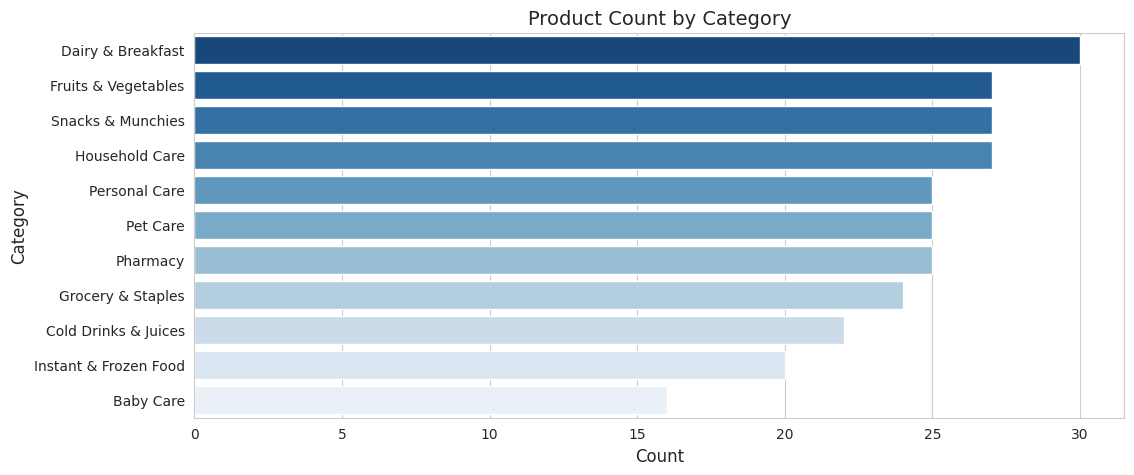

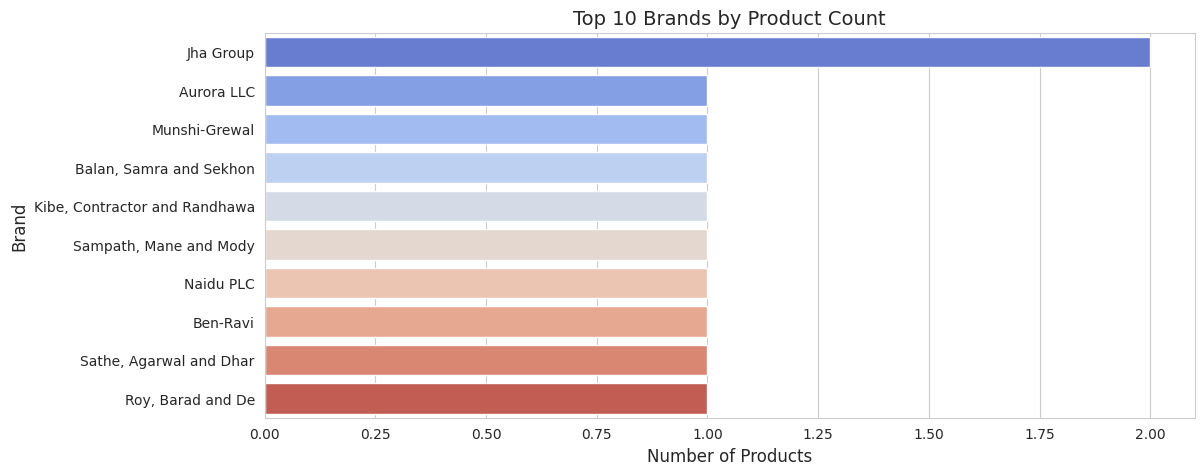

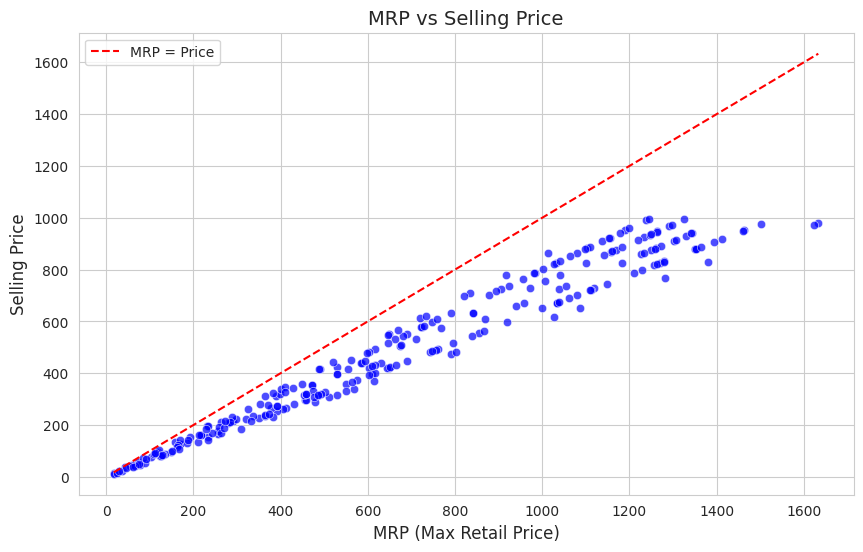

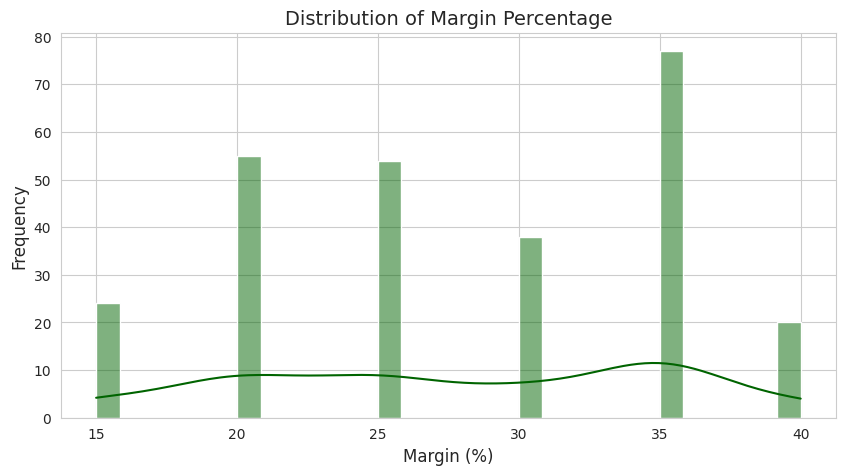

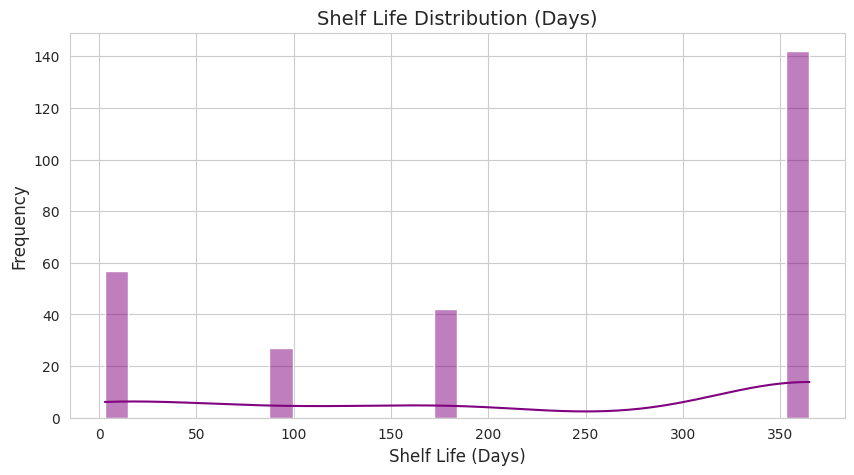

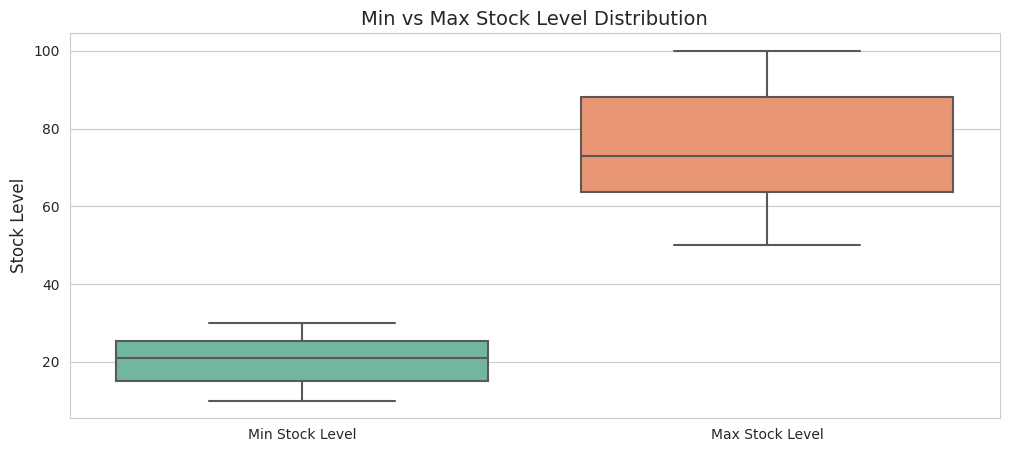

In [11]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# ---- 1. Category-wise Product Distribution ----
plt.figure(figsize=(12, 5))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index, palette="Blues_r")
plt.title("Product Count by Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

# ---- 2. Brand-wise Product Count (Top 10 Brands) ----
top_brands = df["brand"].value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="coolwarm")
plt.title("Top 10 Brands by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.show()

# ---- 3. Price vs MRP Scatter Plot ----
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="mrp", y="price", alpha=0.7, color="blue")
plt.plot([df["mrp"].min(), df["mrp"].max()], [df["mrp"].min(), df["mrp"].max()], "r--", label="MRP = Price")
plt.title("MRP vs Selling Price")
plt.xlabel("MRP (Max Retail Price)")
plt.ylabel("Selling Price")
plt.legend()
plt.show()

# ---- 4. Margin Percentage Distribution ----
plt.figure(figsize=(10, 5))
sns.histplot(df["margin_percentage"], bins=30, kde=True, color="darkgreen")
plt.title("Distribution of Margin Percentage")
plt.xlabel("Margin (%)")
plt.ylabel("Frequency")
plt.show()

# ---- 5. Shelf Life Distribution ----
plt.figure(figsize=(10, 5))
sns.histplot(df["shelf_life_days"], bins=30, kde=True, color="purple")
plt.title("Shelf Life Distribution (Days)")
plt.xlabel("Shelf Life (Days)")
plt.ylabel("Frequency")
plt.show()

# ---- 6. Min vs Max Stock Level ----
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[["min_stock_level", "max_stock_level"]], palette="Set2")
plt.title("Min vs Max Stock Level Distribution")
plt.ylabel("Stock Level")
plt.xticks(ticks=[0, 1], labels=["Min Stock Level", "Max Stock Level"])
plt.show()

In [12]:
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

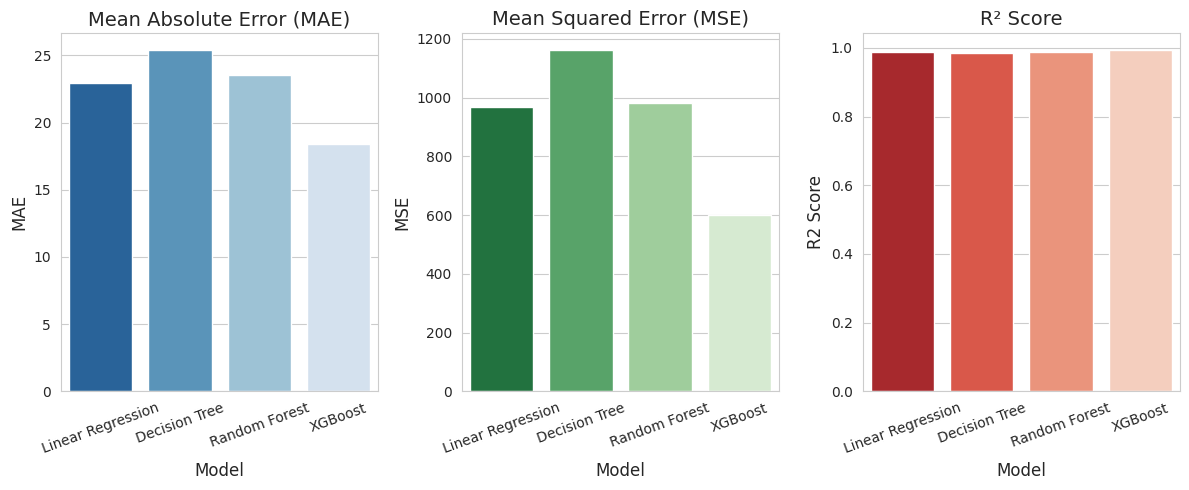

In [13]:
# Ignore warnings
warnings.filterwarnings("ignore")

# Load dataset
file_path = "/kaggle/input/blinkit-sales-dataset/blinkit_products.csv"
df = pd.read_csv(file_path)

# Handle Missing Values
df.dropna(inplace=True)

# Label Encoding for Categorical Features
encoder_category = LabelEncoder()
encoder_brand = LabelEncoder()

df["category"] = encoder_category.fit_transform(df["category"])
df["brand"] = encoder_brand.fit_transform(df["brand"])

# Feature Selection
X = df.drop(columns=["product_id", "product_name", "price"])  # Features
y = df["price"]  # Target variable

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train ML Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "MAE": mae, "MSE": mse, "R2 Score": r2})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# ---- Visualization ----
plt.figure(figsize=(12, 5))

# Bar chart for MAE
plt.subplot(1, 3, 1)
sns.barplot(data=results_df, x="Model", y="MAE", palette="Blues_r")
plt.title("Mean Absolute Error (MAE)")
plt.xticks(rotation=20)

# Bar chart for MSE
plt.subplot(1, 3, 2)
sns.barplot(data=results_df, x="Model", y="MSE", palette="Greens_r")
plt.title("Mean Squared Error (MSE)")
plt.xticks(rotation=20)

# Bar chart for R2 Score
plt.subplot(1, 3, 3)
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="Reds_r")
plt.title("R² Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()
